In [1]:
from utils import *

### fish01 
8dpf huc:h2b-gc7f CID 7694
- ch1 ch2 0.1-1000Hz; both are good, ch2 may be better
- the fish was recorded about two hours after paralysis
- The fish is hypoxic, obvious swim EEG in the beginning of ZTS1

ZTS1-oxygen-spon, 2 hours
- continuous open-loop visual stimulation, vel 0.5
- gc7f imging at 2.4Hz, 61 planes/stack, 300um, 5um step
- 0-1200sec: 16 mg/L high O2 water; many swims
- 1200-2400sec: low O2 water; gradually fewer swims; more rest EEG
- 2400-4800sec: 16 mg/L high O2 water; many swims
- 4800-6000sec: low O2 water; gradually fewer swims; more rest EEG
- 2400-4800sec: 16 mg/L high O2 water; no swims and EEG in the beginning of water switch; and more swims later

In [3]:
idx = 3
row = df.iloc[idx]
save_root = row['save_root']

ephys_data = File(save_root + 'data.mat', 'r')['data']
locs_cam = File(save_root + 'locs_cam.mat', 'r')['locs_cam'][()].squeeze()

fltCh1 = ephys_data['fltCh2'][()].squeeze()
back1 = ephys_data['back2'][()].squeeze()
swim_ = (fltCh1-back1)*10000
swim_[swim_<0]=0

swim_start_idx = ephys_data['swimStartIndT2'][()].squeeze()
swim_end_idx = ephys_data['swimEndIndT2'][()].squeeze()
swim_start = swim_start_idx/6000
swim_end = swim_end_idx/6000
swim_bout_power = ephys_data['swimPower2'][()].squeeze()

swim_intv = np.diff(swim_start)
swim_intv_before = np.r_[swim_intv[0], swim_intv]
swim_intv = np.r_[swim_intv, swim_intv[-1]]

swim_bout_length = swim_end - swim_start

# # plot(locs_cam/6000, F)
# time_ = np.arange(len(swim_))/6000
# plt.plot(time_, swim_)
# plt.xlabel('Time (s)')
# plt.ylabel('Swim power')
# sns.despine()
# plt.show()

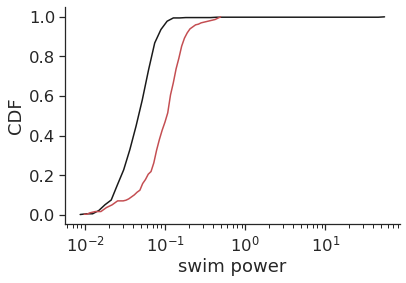

In [4]:
idx = swim_start<1200
x, y = ecdf(np.log(swim_bout_power[idx]))
plt.semilogx(np.exp(x), y, '-k')

idx = (swim_start>1500) & (swim_start<2400)
x, y = ecdf(np.log(swim_bout_power[idx]))
plt.semilogx(np.exp(x), y, '-r')

plt.xlabel('swim power')
plt.ylabel('CDF')
# plt.xlim([0, 2])
sns.despine()
plt.show()

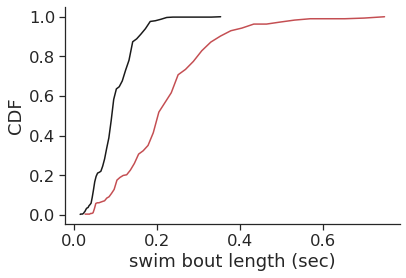

In [5]:
idx = swim_start<1200
x, y = ecdf(np.log(swim_bout_length[idx]))
plt.plot(np.exp(x), y, '-k')

idx = (swim_start>1500) & (swim_start<2400)
x, y = ecdf(np.log(swim_bout_length[idx]))
plt.plot(np.exp(x), y, '-r')

plt.xlabel('swim bout length (sec)')
plt.ylabel('CDF')
# plt.xlim([0, 2])
sns.despine()
plt.show()

In [6]:
u_bout_power = 0.05
l_bout_power = 0.09

idx = swim_start<1000
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power)
print('inter-swim-interval')
print(np.mean(swim_intv[idx]))


idx = (swim_start>1500) & (swim_start<2400)
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power)
print('inter-swim-interval')
print(np.mean(swim_intv[idx]))

inter-swim-interval
2.0779116022099413
inter-swim-interval
3.290756250000044


In [7]:
swim_intv_thres = 1.0

In [14]:
u_bout_power = 0.05
l_bout_power = 0.09
u_swim_bout_ = 0.13
l_swim_bout_ = 0.18
u_swim_bout = 0.13
l_swim_bout = 0.18

idx = swim_start<1200
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power)
idx = idx & (swim_bout_length>u_swim_bout) & (swim_bout_length<l_swim_bout)
print('inter-swim-interval')
print(np.mean(swim_intv[idx]))


idx = (swim_start>1500) & (swim_start<2400)
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power)
idx = idx & (swim_bout_length>u_swim_bout_) & (swim_bout_length<l_swim_bout_)
print('inter-swim-interval')
print(np.mean(swim_intv[idx]))

inter-swim-interval
1.746462745098038
inter-swim-interval
4.472913978494651


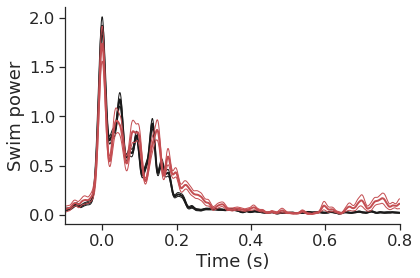

In [15]:
idx = swim_start<1200
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx = idx & (swim_bout_length>u_swim_bout) & (swim_bout_length<l_swim_bout)
idx_ = np.where(idx)[0]
swim_start_idx = swim_start_idx.astype('int')

num_sample = len(idx_)
xq = np.arange(-600,4800)/6000;
xq_ = len(xq)
dat_ = np.zeros((num_sample, xq_))

for n in range(num_sample):
    swim_time_start = swim_start_idx[idx_[n]]-600
    dat_[n] = swim_[swim_time_start:swim_time_start+xq_]

mean_ = np.mean(dat_, axis=0);
sem_ = np.std(dat_, axis=0)/np.sqrt(num_sample);
plt.plot(xq, mean_, '-k', lw=2);
plt.plot(xq, mean_+sem_, '-k', lw=1)
plt.plot(xq, mean_-sem_, '-k', lw=1)

idx = (swim_start>1500) & (swim_start<2400)
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx = idx & (swim_bout_length>u_swim_bout_) & (swim_bout_length<l_swim_bout_)
idx_ = np.where(idx)[0]
swim_start_idx = swim_start_idx.astype('int')

num_sample = len(idx_)
xq = np.arange(-600,4800)/6000;
xq_ = len(xq)
dat_ = np.zeros((num_sample, xq_))

for n in range(num_sample):
    swim_time_start = swim_start_idx[idx_[n]]-600
    dat_[n] = swim_[swim_time_start:swim_time_start+xq_]

mean_ = np.mean(dat_, axis=0);
sem_ = np.std(dat_, axis=0)/np.sqrt(num_sample);
plt.plot(xq, mean_, '-r', lw=2);
plt.plot(xq, mean_+sem_, '-r', lw=1)
plt.plot(xq, mean_-sem_, '-r', lw=1)


plt.xlabel('Time (s)')
plt.ylabel('Swim power')
plt.xlim([-0.1, 0.8])
sns.despine()
plt.show()

In [16]:
idx = swim_start<1000
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
print('average swim power')
print(np.mean(swim_bout_power[idx]))
print('# trials')
print(np.sum(idx))

idx = (swim_start>1500) & (swim_start<2400)
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
print('average swim power')
print(np.mean(swim_bout_power[idx]))
print('# trials')
print(np.sum(idx))

average swim power
0.06507048115639685
# trials
177
average swim power
0.07240306625034758
# trials
71


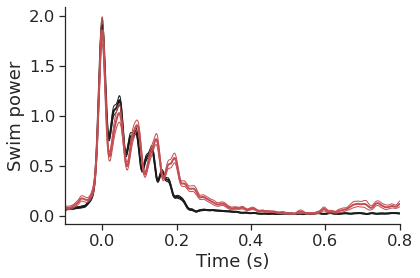

In [17]:
idx = swim_start<1000
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx_ = np.where(idx)[0]
swim_start_idx = swim_start_idx.astype('int')

num_sample = len(idx_)
xq = np.arange(-600,4800)/6000;
xq_ = len(xq)
dat_ = np.zeros((num_sample, xq_))

for n in range(num_sample):
    swim_time_start = swim_start_idx[idx_[n]]-600
    dat_[n] = swim_[swim_time_start:swim_time_start+xq_]

mean_ = np.mean(dat_, axis=0);
sem_ = np.std(dat_, axis=0)/np.sqrt(num_sample);
plt.plot(xq, mean_, '-k', lw=2);
plt.plot(xq, mean_+sem_, '-k', lw=1)
plt.plot(xq, mean_-sem_, '-k', lw=1)

idx = (swim_start>1500) & (swim_start<2400)
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx_ = np.where(idx)[0]
swim_start_idx = swim_start_idx.astype('int')

num_sample = len(idx_)
xq = np.arange(-600,4800)/6000;
xq_ = len(xq)
dat_ = np.zeros((num_sample, xq_))

for n in range(num_sample):
    swim_time_start = swim_start_idx[idx_[n]]-600
    dat_[n] = swim_[swim_time_start:swim_time_start+xq_]

mean_ = np.mean(dat_, axis=0);
sem_ = np.std(dat_, axis=0)/np.sqrt(num_sample);
plt.plot(xq, mean_, '-r', lw=2);
plt.plot(xq, mean_+sem_, '-r', lw=1)
plt.plot(xq, mean_-sem_, '-r', lw=1)


plt.xlabel('Time (s)')
plt.ylabel('Swim power')
plt.xlim([-0.1, 0.8])
sns.despine()
plt.show()

In [18]:
dFF_ = np.load(save_root + 'cell_dff.npz', allow_pickle=True)['dFF'].astype('float')
A_center = np.load(save_root+'cell_center.npy')
num_cells = dFF_.shape[0]
valid_F = np.ones(num_cells).astype('bool')
for n_ in range(num_cells):
    if np.isnan(dFF_[n_]).sum()>0:
        valid_F[n_] = False
vdFF_ = dFF_[valid_F]
dFF_ = None

In [19]:
F_cond1 = []
idx = swim_start<1200
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx_ = np.where(idx)[0]
num_sample = len(idx_)

for n in range(num_sample):
    swim_time_start = swim_start_idx[idx_[n]]
    F_idx = (locs_cam<=swim_time_start).sum()
    if F_idx==0:
        continue
    F_cond1_ = vdFF_[:, F_idx+1:F_idx+3].mean(axis=1) - vdFF_[:, F_idx-3:F_idx-1].mean(axis=1)
    F_cond1.append(F_cond1_)
F_cond1 = np.array(F_cond1)
    
F_cond2 = []
idx = (swim_start>1500) & (swim_start<2400)
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx_ = np.where(idx)[0]
num_sample = len(idx_)

for n in range(num_sample):
    swim_time_start = swim_start_idx[idx_[n]]
    F_idx = (locs_cam<=swim_time_start).sum()
    if F_idx==0:
        continue
    F_cond2_ = vdFF_[:, F_idx+1:F_idx+3].mean(axis=1) - vdFF_[:, F_idx-3:F_idx-1].mean(axis=1)
    F_cond2.append(F_cond2_)
F_cond2 = np.array(F_cond2)

In [20]:
num_cells = vdFF_.shape[0]
sig_cells = np.zeros(num_cells)

for n_ in tqdm(range(num_cells)):
    _, p = mannwhitneyu(F_cond1[:, n_], F_cond2[:, n_])
    sig_cells[n_] = p

100%|██████████| 482593/482593 [13:49<00:00, 581.91it/s]  


In [21]:
u_bout_power = 0.05
l_bout_power = 0.09
u_swim_bout_ = 0.13
l_swim_bout_ = 0.18
u_swim_bout = 0.13
l_swim_bout = 0.18

idx = swim_start<1200
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx = idx & (swim_bout_length>u_swim_bout) & (swim_bout_length<l_swim_bout)
idx_ = np.where(idx)[0]
idx1 = idx_ 

idx = (swim_start>1500) & (swim_start<2400)
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx = idx & (swim_bout_length>u_swim_bout_) & (swim_bout_length<l_swim_bout_)
idx_ = np.where(idx)[0]
idx2 = idx_

In [22]:
u_bout_power = 0.05
l_bout_power = 0.09

idx = swim_start<1200
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx_ = np.where(idx)[0]
idx1_ = idx_ 

idx = (swim_start>1500) & (swim_start<2400)
idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
idx_ = np.where(idx)[0]
idx2_ = idx_

In [23]:
np.savez(save_root+'/motor_clamp_sig_cells.npz', \
         valid_F=valid_F, sig_cells=sig_cells, \
         idx1=idx1, idx2=idx2, \
         idx1_=idx1_, idx2_=idx2_)

In [25]:
# print((sig_cells<0.01).mean())
# brain_map = np.load(save_root+'Y_ave.npy').astype('float')

# sig_cells_ = sig_cells<0.01
# plt.figure(figsize=(20, 10))
# plt.imshow(brain_map.max(0), cmap='gray', origin='lower', aspect='auto')
# plt.scatter(A_center[valid_F][sig_cells_][:,1], A_center[valid_F][sig_cells_][:,2], \
#             c=-np.log10(sig_cells[sig_cells_]), s=1, vmax=5, vmin=2)
# plt.axis('off')
# sns.despine()
# plt.show()

# # plt.imshow(brain_map.max(2))
# # plt.scatter(A_center[valid_F][sig_cells_][:,2], A_center[valid_F][sig_cells_][:,0], s=1)
# # sns.despine()
# # plt.show()

# plt.figure(figsize=(20, 6))
# plt.imshow(brain_map.max(1), cmap='gray', origin='lower', aspect='auto')
# plt.scatter(A_center[valid_F][sig_cells_][:,1], A_center[valid_F][sig_cells_][:,0], \
#             c=-np.log10(sig_cells[sig_cells_]), s=1, vmax=5, vmin=2)
# plt.axis('off')
# sns.despine()
# plt.show()

In [15]:
# from scipy.interpolate import interp1d
# sig_F = dFF_[valid_F][sig_cells<0.01].mean(axis=0)
# xq = np.arange(-0.3, 1.5, 0.01)
# t0 = np.sum(xq<=0)

# idx = swim_start<1000
# idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
# idx_ = np.where(idx)[0]
# num_sample = len(idx_)
# dat_ = np.zeros((num_sample, len(xq)))
# dat_[:] = np.nan

# for n in range(num_sample):
#     F_time_start = swim_start_idx[idx_[n]]
#     F_idx = (locs_cam>=F_time_start-6000) & (locs_cam<=F_time_start+12000)
#     if sum(F_idx)<3:
#         continue
#     if locs_cam[F_idx][0]>F_time_start:
#         continue
#     F_time_ = (locs_cam[F_idx] - F_time_start)/6000;
#     F_ = sig_F[F_idx]
#     dat_[n] = interp1d(F_time_,F_)(xq)
#     dat_[n] = dat_[n] - dat_[n][t0-20:t0].mean()
    
# mean_ = np.nanmean(dat_, axis=0);
# sem_ = np.nanstd(dat_, axis=0)/np.sqrt(np.sum(~np.isnan(dat_), axis=0))
# plt.plot(xq, mean_, '-k', lw=2);
# plt.plot(xq, mean_+sem_, '-k', lw=1)
# plt.plot(xq, mean_-sem_, '-k', lw=1)

# idx = (swim_start>1500) & (swim_start<2400)
# idx = idx & (swim_bout_power>u_bout_power) & (swim_bout_power<l_bout_power) & (swim_intv>swim_intv_thres)
# idx_ = np.where(idx)[0]
# num_sample = len(idx_)
# dat_ = np.zeros((num_sample, len(xq)))
# dat_[:] = np.nan

# for n in range(num_sample):
#     F_time_start = swim_start_idx[idx_[n]]
#     F_idx = (locs_cam>=F_time_start-6000) & (locs_cam<=F_time_start+12000)
#     if sum(F_idx)<3:
#         continue
#     F_time_ = (locs_cam[F_idx] - F_time_start)/6000;
#     F_ = sig_F[F_idx]
#     dat_[n] = interp1d(F_time_,F_)(xq)
#     dat_[n] = dat_[n] - dat_[n][t0-20:t0-10].mean()
    
# mean_ = np.nanmean(dat_, axis=0);
# sem_ = np.nanstd(dat_, axis=0)/np.sqrt(np.sum(~np.isnan(dat_), axis=0))
# plt.plot(xq, mean_, '-r', lw=2);
# plt.plot(xq, mean_+sem_, '-r', lw=1)
# plt.plot(xq, mean_-sem_, '-r', lw=1)


# plt.xlabel('Time (s)')
# plt.ylabel('dF/F')
# plt.xlim([-0.3, 1.5])
# sns.despine()
# plt.show()